[08:00:17] [*] Loading UNSW-NB15 Dataset...
[+] Dataset loaded. Total records: 257673

[*] Exploratory Data Analysis (EDA):
------------------------------
DATA HEAD:
        dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0  0.121478   tcp       -   FIN      6      4     258     172  74.087486   
1  0.649902   tcp       -   FIN     14     38     734   42014  78.473373   
2  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4  0.449454   tcp       -   FIN     10      6     534     268  33.373825   

          sload  ...  trans_depth  response_body_len  ct_src_dport_ltm  \
0  14158.942383  ...            0                  0                 1   
1   8395.112305  ...            0                  0                 1   
2   1572.271851  ...            0                  0                 1   
3   2740.178955  ...            0                  0                 1   
4   856

/tmp/ipykernel_1967/520994941.py:43: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df = df.replace('-', 0)


[+] Normalization completed.
[08:00:18] [*] Training Random Forest Classifier...
[+] Training completed in 49.24 seconds.

FINAL SYSTEM ACCURACY: 93.94%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     18613
           1       0.95      0.95      0.95     32922

    accuracy                           0.94     51535
   macro avg       0.93      0.93      0.93     51535
weighted avg       0.94      0.94      0.94     51535



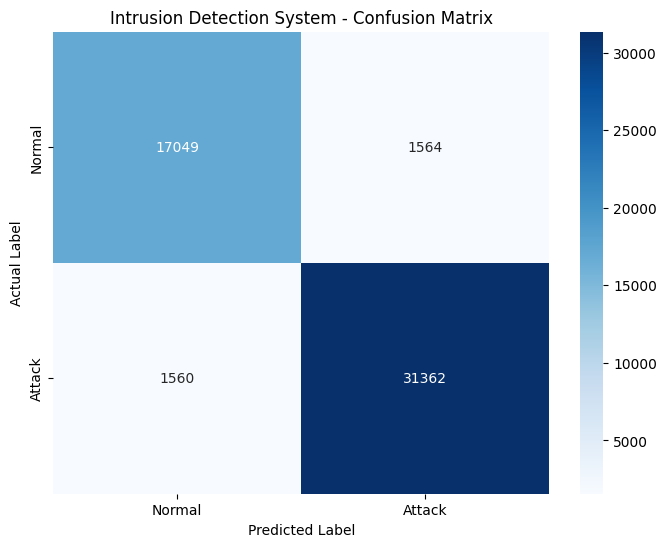

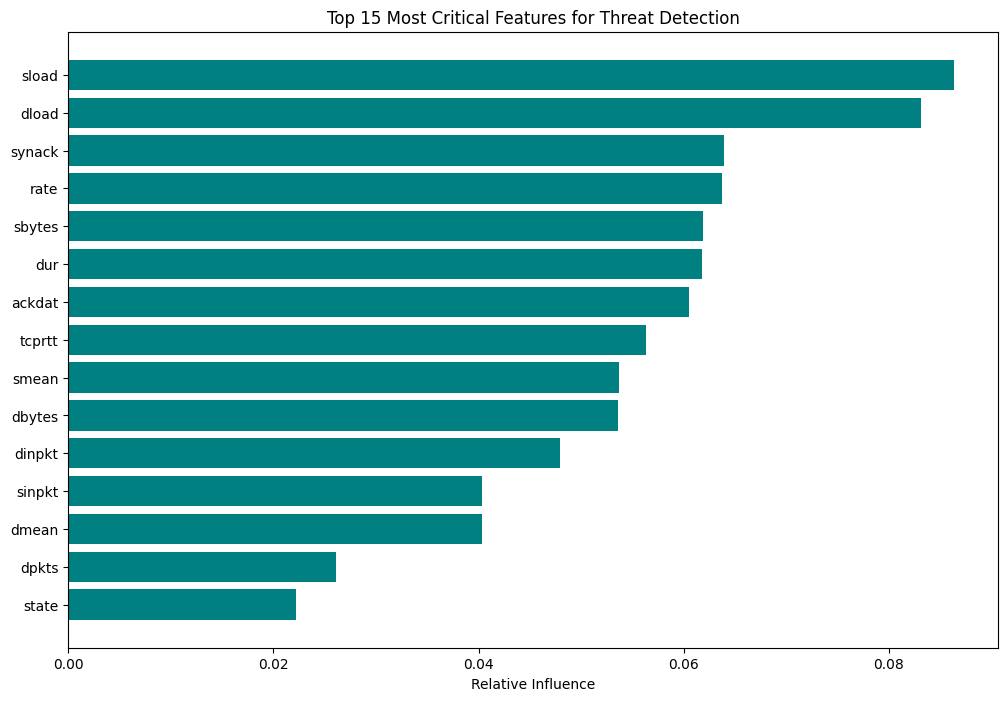


[ANALYSIS] Packet #10 details:
Prediction: ATTACK
----------------------------------------
Decision Factors (Top 5):
-> sload: 470666656.0 (Weight: 0.0863)
-> dload: 0.0 (Weight: 0.0831)
-> synack: 0.0 (Weight: 0.0639)
-> rate: 83333.328125 (Weight: 0.0637)
-> sbytes: 1412.0 (Weight: 0.0619)

[08:01:09] [+] Success: Model and Scaler exported for deployment.


In [16]:
import pandas as pd
import numpy as np
import joblib
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# PHASE 1: DATA ACQUISITION & INSPECTION
# ==========================================
print(f"[{time.strftime('%H:%M:%S')}] [*] Loading UNSW-NB15 Dataset...")

# Loading parquet files (optimized for performance)
train_df = pd.read_parquet('UNSW_NB15_training-set.parquet')
test_df = pd.read_parquet('UNSW_NB15_testing-set.parquet')

# Merging for unified preprocessing
df = pd.concat([train_df, test_df], axis=0)
print(f"[+] Dataset loaded. Total records: {len(df)}")

print("\n[*] Exploratory Data Analysis (EDA):")
print("-" * 30)
print("DATA HEAD:")
print(df.head())
print("-" * 30)
print("DATA TAIL:")
print(df.tail())

# ==========================================
# PHASE 2: DATA PREPROCESSING & CLEANING
# ==========================================
print(f"\n[{time.strftime('%H:%M:%S')}] [*] Cleaning and Encoding Features...")

# Remove multiclass target if it exists (Focusing on Binary Classification: Normal vs Attack)
if 'attack_cat' in df.columns:
    df = df.drop(['attack_cat'], axis=1)

# Fix common data issues in UNSW-NB15 (replacing '-' with 0)
df = df.replace('-', 0)

# Convert categorical labels to numerical values
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Ensure all columns are numeric for the scaler
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

# ==========================================
# PHASE 3: FEATURE SCALING & SPLITTING
# ==========================================
X = df.drop('label', axis=1)
y = df['label']
feature_names = X.columns

# Split data (80% Train, 20% Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalization (Standardization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
print("[+] Normalization completed.")

# ==========================================
# PHASE 4: MODEL TRAINING
# ==========================================
start_time = time.time()
print(f"[{time.strftime('%H:%M:%S')}] [*] Training Random Forest Classifier...")

model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

end_time = time.time()
print(f"[+] Training completed in {end_time - start_time:.2f} seconds.")

# ==========================================
# PHASE 5: EVALUATION & VISUALIZATION
# ==========================================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100

print(f"\n{'='*40}")
print(f"FINAL SYSTEM ACCURACY: {accuracy:.2f}%")
print(f"{'='*40}\n")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# 1. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Intrusion Detection System - Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 2. Feature Importance Visualization
plt.figure(figsize=(12, 8))
importances = model.feature_importances_
indices = np.argsort(importances)[-15:] # Top 15 features
plt.title('Top 15 Most Critical Features for Threat Detection')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Influence')
plt.show()

# ==========================================
# PHASE 6: EXPLAINABLE AI (XAI) FUNCTION
# ==========================================
def explain_packet_decision(sample_index):
    """
    Explains the model's logic for a specific prediction.
    """
    prediction = model.predict(X_test[sample_index].reshape(1, -1))[0]
    label = "ATTACK" if prediction == 1 else "NORMAL"

    print(f"\n[ANALYSIS] Packet #{sample_index} details:")
    print(f"Prediction: {label}")
    print("-" * 40)

    # Identify top influencing features for this specific packet
    importances = model.feature_importances_
    top_indices = np.argsort(importances)[-5:][::-1]

    print("Decision Factors (Top 5):")
    for i in top_indices:
        val = X_test_raw.iloc[sample_index][feature_names[i]]
        print(f"-> {feature_names[i]}: {val} (Weight: {importances[i]:.4f})")

# Example: Explain a prediction for a random packet in the test set
explain_packet_decision(10)

# ==========================================
# PHASE 7: EXPORTING MODEL
# ==========================================
joblib.dump(model, 'final_ids_model.pkl')
joblib.dump(scaler, 'final_scaler.pkl')
print(f"\n[{time.strftime('%H:%M:%S')}] [+] Success: Model and Scaler exported for deployment.")

In [17]:
df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
0,0.121478,113,0.0,4,6,4,258,172,74.087486,14158.942383,...,43,0,0,1,1,0,0,0,0,0
1,0.649902,113,0.0,4,14,38,734,42014,78.473373,8395.112305,...,1106,0,0,1,1,0,0,0,0,0
2,1.623129,113,0.0,4,8,16,364,13186,14.170161,1572.271851,...,824,0,0,1,1,0,0,0,0,0
3,1.681642,113,0.0,4,12,12,628,770,13.677108,2740.178955,...,64,0,0,1,1,1,1,0,0,0
4,0.449454,113,0.0,4,10,6,534,268,33.373825,8561.499023,...,45,0,0,2,1,0,0,0,0,0
